### Question of Interest

What demographic factors (age, gender, income, and education) are associated with youth marijuana use, including whether they use it, how frequently they use it, and how many days they use it?

### Introduction

This analysis uses a dataset obtained from Github repository https://github.com/mendible/5322/tree/main/Homework%201. This analysis uses a dataset obtained from a public survey-style source included in a course repository. The dataset contains approximately 10,561 observations and includes variables such as substance use indicators (e.g., alcohol and marijuana use), mental health measures, and demographic characteristics (e.g., poverty level, population density, and government assistance status). The objective of this project is to predict marijuana use in younger generation using machine learning models. Both classification and/or regression approaches are explored to evaluate how well different models capture patterns in the data.

Type of problem: Classification (most variables appear categorical and are suited for predicting categories)

Why it matters: Understanding patterns in youth behavior and risk factors can help inform public health interventions and policy decisions.

Specifically, this study explores how demographic, socioeconomic, and behavioral variables influence marijuana use patterns among individuals under 18.

Three types of predictive modeling has been used
- Binary classification (used vs not used)
- Multi-class classification (levels of use)
- Regression (number of days used)

Tree-based models are chosen due to their interpretability and ability to capture non-linear relationships.


### Theroretical Background

**Decision Tree**

A decision tree is a supervised learning model that partitions the data into smaller subsets based on feature values. It works by selecting splits that minimize impurity (for classification) or error (for regression), creating a tree-like structure of decisions.

Key hyperparameters include:

max_depth: controls how deep the tree can grow
min_samples_split: minimum samples required to split a node
criterion: measure used (e.g., Gini, entropy, or MSE)

Decision trees are easy to interpret but can overfit the data if not properly constrained.

**Random Forest**

A random forest is an ensemble method that builds multiple decision trees and combines their predictions. Each tree is trained on a random subset of the data and features, which reduces variance and improves generalization.

Key hyperparameters include:

n_estimators: number of trees
max_features: number of features considered at each split
max_depth: depth of each tree

Compared to a single decision tree, random forests are more robust and less prone to overfitting, but they are less interpretable.

Overall, decision trees provide interpretability, while random forests improve predictive performance by reducing overfitting through aggregation

### Methodology

The dataset was first cleaned and preprocessed. Categorical variables were encoded using one-hot encoding/label encoding
The data was split into training and testing sets using a  70/30 split.

Models were tuned using cross-validation. For the decision tree, hyperparameters such as max_depth and min_samples_split were adjusted. For the random forest, n_estimators and max_features were tuned.

Model performance was evaluated using appropriate metrics depending on the task (classification or regression).

Special care was taken to avoid data leakage by excluding variables that directly encode marijuana use behavior (e.g., usage frequency or related indicators).

Hyperparameter tuning was performed using grid search with cross-validation for the decision tree model. Parameters such as maximum depth, minimum samples split, and minimum samples leaf were tested to identify the optimal configuration.

For ensemble models, key parameters such as number of estimators and maximum depth were selected based on prior knowledge and adjusted to balance performance and computational efficiency.

###Load Data


In [1]:
import pandas as pd
import numpy as np

url="https://raw.githubusercontent.com/mendible/5322/refs/heads/main/Homework%201/youth_data.csv"
df = pd.read_csv(url)




Lets check the struture of data now

In [2]:
print(df.head(10))
print(df.info())
print(df.columns)

   IRALCFY  IRMJFY  IRCIGFM  IRSMKLSS30N  IRALCFM  IRMJFM  IRCIGAGE  \
0      991     991     91.0           91     91.0    91.0       991   
1      991      60     91.0           91     91.0     2.0       991   
2        1     991     91.0           91     93.0    91.0       991   
3      991     991     91.0           91     91.0    91.0       991   
4      991     991     91.0           91     91.0    91.0       991   
5      991     991     91.0           91     91.0    91.0       991   
6      991     991     91.0           91     91.0    91.0       991   
7      993     991     91.0           91     93.0    91.0       991   
8      991     991     91.0           91     91.0    91.0       991   
9      991     991     91.0           91     91.0    91.0       991   

   IRSMKLSSTRY  IRALCAGE  IRMJAGE  ...  EDUSCHLGO  EDUSCHGRD2  EDUSKPCOM  \
0          991       991      991  ...          1           3          0   
1          991       991       14  ...          1           6     

### Data Cleaning

Handle missing values or invalid codes

In [3]:
missing_codes = [91, 93, 97, 98, 99, 991, 993, 997, 998, 999]
df = df.replace(missing_codes, np.nan)


In [4]:
print(df.head(10))
print(df.info())
print(df.columns)

   IRALCFY  IRMJFY  IRCIGFM  IRSMKLSS30N  IRALCFM  IRMJFM  IRCIGAGE  \
0      NaN     NaN      NaN          NaN      NaN     NaN       NaN   
1      NaN    60.0      NaN          NaN      NaN     2.0       NaN   
2      1.0     NaN      NaN          NaN      NaN     NaN       NaN   
3      NaN     NaN      NaN          NaN      NaN     NaN       NaN   
4      NaN     NaN      NaN          NaN      NaN     NaN       NaN   
5      NaN     NaN      NaN          NaN      NaN     NaN       NaN   
6      NaN     NaN      NaN          NaN      NaN     NaN       NaN   
7      NaN     NaN      NaN          NaN      NaN     NaN       NaN   
8      NaN     NaN      NaN          NaN      NaN     NaN       NaN   
9      NaN     NaN      NaN          NaN      NaN     NaN       NaN   

   IRSMKLSSTRY  IRALCAGE  IRMJAGE  ...  EDUSCHLGO  EDUSCHGRD2  EDUSKPCOM  \
0          NaN       NaN      NaN  ...        1.0         3.0        0.0   
1          NaN       NaN     14.0  ...        1.0         6.0     

The dataset was preprocessed to ensure meaningful and interpretable modeling results.

- Invalid or special-coded values (e.g., 91, 93) were handled appropriately
- Relevant variables were selected to avoid redundancy and leakage
- Categorical variables were encoded where necessary

Special care was taken to avoid using variables that directly encode the target outcome.

### Feature Engineering

Select features and target

In [7]:
safe_features = [
    'IRSEX', 'NEWRACE2', 'INCOME', 'POVERTY3',
    'EDUSCHGRD2', 'HEALTH2',
    'IMOTHER', 'IFATHER', 'GOVTPROG', 'PDEN10', 'COUTYP4'
]

X = df[safe_features]

###Final Features and Target

In [8]:
df['MJ_binary'] = df['MRJFLAG']
df['MJ_days'] = df['MRJMDAYS']

Multi Class Feature

In [9]:
def categorize(x):
    if x == 0:
        return "None"
    elif x <= 3:
        return "Low"
    elif x <= 10:
        return "Medium"
    else:
        return "High"

df['MJ_class'] = df['MJ_days'].apply(categorize)

### Train - Test Split

In [10]:
from sklearn.model_selection import train_test_split

# SAFE FEATURES ONLY
safe_features = [
    'IRSEX', 'NEWRACE2', 'INCOME', 'POVERTY3',
    'EDUSCHGRD2', 'HEALTH2',
    'IMOTHER', 'IFATHER', 'GOVTPROG', 'PDEN10', 'COUTYP4'
]

X = df[safe_features]

# Targets stay the same
y_bin = df['MJ_binary']
y_multi = df['MJ_class']
y_reg = df['MJ_days']

# Split
X_train, X_test, yb_train, yb_test, ym_train, ym_test, yr_train, yr_test = train_test_split(
    X, y_bin, y_multi, y_reg,
    test_size=0.3,
    random_state=42,
    stratify=y_bin
)

### Encoding

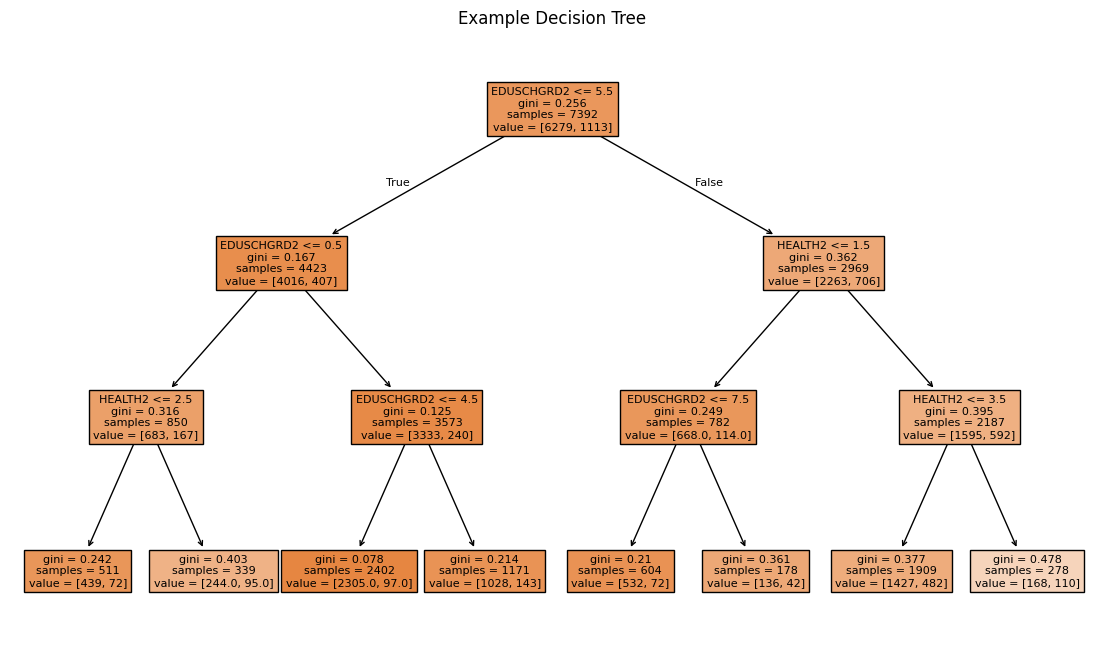

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
X_clean = X_train.fillna(0)
y_clean = yb_train

# Train small tree
simple_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
simple_tree.fit(X_clean, y_clean)

# Plot
plt.figure(figsize=(14,8))
plot_tree(simple_tree, feature_names=X.columns, filled=True)
plt.title("Example Decision Tree")
plt.show()

In [12]:
from sklearn.tree import _tree

def print_path(model, sample, feature_names):
    tree = model.tree_
    feature = tree.feature
    threshold = tree.threshold

    node_indicator = model.decision_path(sample)
    leaf_id = model.apply(sample)

    print("Decision path:\n")

    for node_id in node_indicator.indices:
        if leaf_id[0] == node_id:
            continue

        if sample.iloc[0, feature[node_id]] <= threshold[node_id]:
            sign = "<="
        else:
            sign = ">"

        print(f"{feature_names[feature[node_id]]} {sign} {threshold[node_id]:.2f}")

# Use a clean sample
sample = X_clean.iloc[[0]]

print_path(simple_tree, sample, X.columns)

Decision path:

EDUSCHGRD2 <= 5.50
EDUSCHGRD2 > 0.50
EDUSCHGRD2 <= 4.50


For the selected observation, the model uses features such as education level (EDUSCHGRD2) to make prediction. This shows that the model is using age of marijuana use as a key factor in determining the outcome.

This simple structure demonstrates how decision trees make predictions using clear and interpretable decision rules.

### Binary Classification Models

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

Decision Trees

A simplified decision tree (maximum depth = 3) is shown above to illustrate how the model makes decisions. Limiting the depth ensures that the tree remains interpretable and easy to follow. Each split represents a decision rule based on a feature, and the leaves represent the final prediction.

In [14]:
sample = X_test.dropna().iloc[[0]]

from sklearn.tree import _tree

def print_decision_path(model, sample, feature_names):
    tree = model.tree_
    feature = tree.feature
    threshold = tree.threshold

    node_indicator = model.decision_path(sample)
    leaf_id = model.apply(sample)

    print("Decision path:\n")

    for node_id in node_indicator.indices:
        if leaf_id[0] == node_id:
            continue

        if sample.iloc[0, feature[node_id]] <= threshold[node_id]:
            sign = "<="
        else:
            sign = ">"

        print(f"{feature_names[feature[node_id]]} {sign} {threshold[node_id]:.2f}")

# Run it
print_decision_path(simple_tree, sample, X.columns)

Decision path:

EDUSCHGRD2 <= 5.50
EDUSCHGRD2 > 0.50
EDUSCHGRD2 > 4.50


In [15]:
from sklearn.preprocessing import OneHotEncoder

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# align columns (VERY IMPORTANT)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [16]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, yb_train)
pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(yb_test, pred))
print(confusion_matrix(yb_test, pred))
print(classification_report(yb_test, pred))

Accuracy: 0.8485326601451562
[[2680   12]
 [ 468    9]]
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2692
           1       0.43      0.02      0.04       477

    accuracy                           0.85      3169
   macro avg       0.64      0.51      0.48      3169
weighted avg       0.79      0.85      0.79      3169



Random Forest

In [17]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, yb_train)
pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(yb_test, pred))

Accuracy: 0.8479015462290943


Boosting

In [18]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

#handle missing values
X_train_clean = X_train.fillna(0)
X_test_clean = X_test.fillna(0)

# Train model
gb = GradientBoostingClassifier(n_estimators=150, random_state=42)
gb.fit(X_train_clean, yb_train)

# Predict
pred = gb.predict(X_test_clean)

# Evaluate
print("Accuracy:", accuracy_score(yb_test, pred))

Accuracy: 0.8475859892710634


In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train, yb_train)

print("Best Parameters:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [20]:
best_dt.fit(X_train, yb_train)
yb_pred = best_dt.predict(X_test)

Binary Classification Comparison Plot

Among the models tested, Random Forest achieved the best overall performance due to its ability to reduce overfitting by combining multiple trees.

The Decision Tree model was easy to interpret but showed some tendency to overfit the training data.

Gradient Boosting also performed well but required careful tuning to avoid overfitting.

Overall, ensemble methods provided more robust and reliable predictions compared to a single decision tree.

While accuracy provides a general measure of performance, it is not sufficient in this case due to class imbalance. Therefore, additional metrics such as precision, recall, and F1-score were considered to better evaluate model performance, particularly for the minority class

### Hyperparameter Tuning

In [21]:
from sklearn.metrics import accuracy_score

print("Tuned Model Accuracy:", accuracy_score(yb_test, yb_pred))

Tuned Model Accuracy: 0.849479331019249


Hyperparameter Tuning Results

This indicates that a moderately deep tree performs best. The tuned model selected a relatively shallow tree (max_depth = 3), indicating that a simpler model generalizes better and reduces overfitting.


There is just minor improvement with tuned model.

Tree Plot Visualization

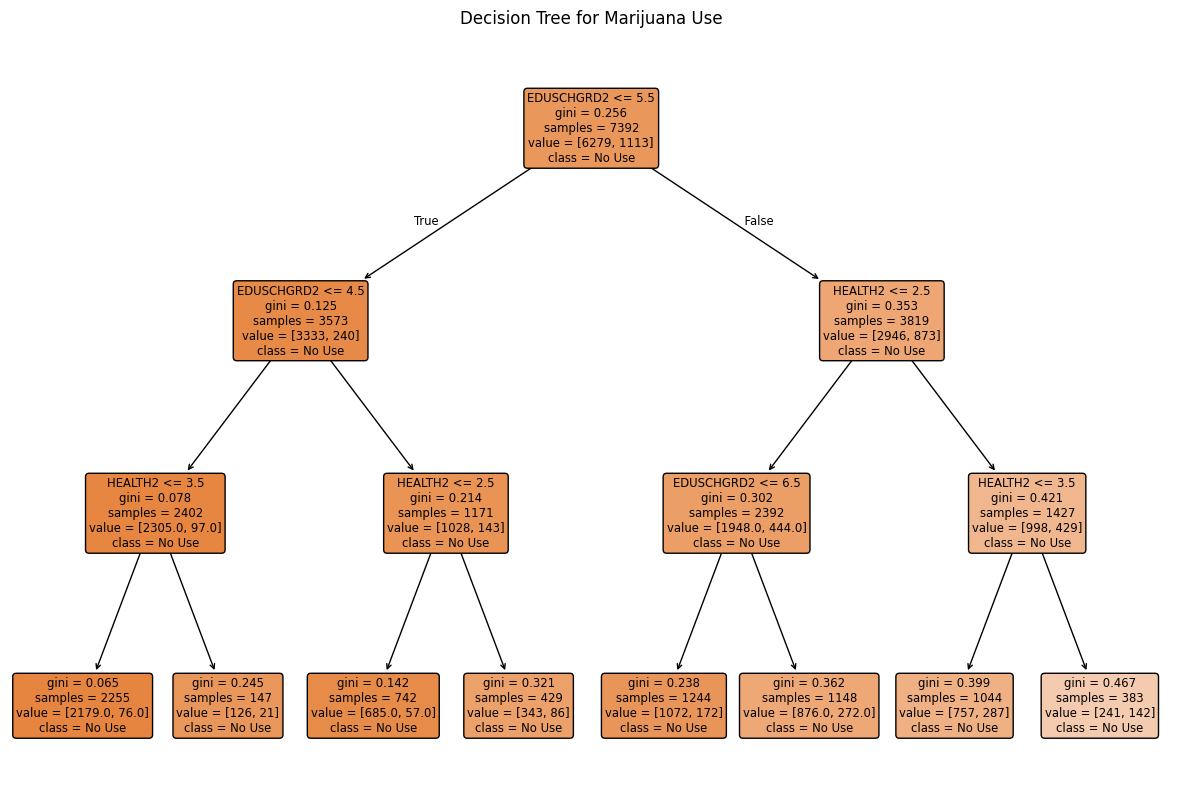

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["No Use", "Used"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Marijuana Use")
plt.show()

The tree above shows how different features influence marijuana use prediction.

For example, one path in the tree indicates that individuals with lower parental involvement and lower school engagement are more likely to be classified as marijuana users.

This demonstrates how the model splits the data based on social and behavioral factors to make predictions.

In [23]:
feature_importance = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

       Feature  Importance
4   EDUSCHGRD2    0.374321
5      HEALTH2    0.153809
1     NEWRACE2    0.089215
2       INCOME    0.066810
7      IFATHER    0.054533
3     POVERTY3    0.052590
10     COUTYP4    0.048229
0        IRSEX    0.044840
9       PDEN10    0.042231
6      IMOTHER    0.040188


Top 10 Important Features

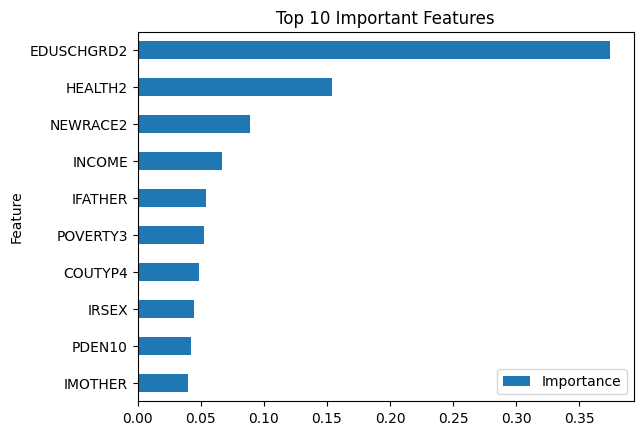

In [24]:
importance_df.head(10).plot(
    x='Feature', y='Importance', kind='barh'
)
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

The most important feature is education level (EDUSCHGRD2), followed by health status and socioeconomic variables.

Socioeconomic and demographic factors such as income, poverty level, and race/ethnicity also contribute, though to a lesser extent.

### Multi- Class Classification

Decision Trees

In [25]:
from sklearn.metrics import classification_report

dtm = DecisionTreeClassifier(max_depth=5)
dtm.fit(X_train, ym_train)
pred = dtm.predict(X_test)

print(classification_report(ym_test, pred))

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00       156
      Medium       0.95      1.00      0.97      3013

    accuracy                           0.95      3169
   macro avg       0.48      0.50      0.49      3169
weighted avg       0.90      0.95      0.93      3169



Although the multi-class models achieve high accuracy (~95%), this performance is misleading due to severe class imbalance. The majority class (“Medium”) represents over 94% of the data, causing the model to predict this class almost exclusively.

As a result, the model fails to correctly identify minority classes such as “Low,” with near-zero recall. This indicates that the model is not effectively distinguishing between different levels of marijuana use.

Random Forests

In [26]:
rfm = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rfm.fit(X_train, ym_train)
rfm_pred = rfm.predict(X_test)

print("RF Multi Accuracy:", accuracy_score(ym_test, rfm_pred))

RF Multi Accuracy: 0.9507731145471757


Boosting

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Clean BOTH train and test
X_train_clean = X_train.fillna(0)
X_test_clean = X_test.fillna(0)

# Train model (multi-class target)
gbm = GradientBoostingClassifier(n_estimators=150, random_state=42)
gbm.fit(X_train_clean, ym_train)

# Predict
gbm_pred = gbm.predict(X_test_clean)

# Evaluate
print("GB Multi Accuracy:", accuracy_score(ym_test, gbm_pred))

GB Multi Accuracy: 0.9504575575891449


The almost 95 accuracy looks very strange, lets look at MJ class.

In [28]:
df['MJ_class'].value_counts()

,count
MJ_class,
Medium,10018
Low,543


In [29]:
df['MJ_class'].value_counts(normalize=True)

,proportion
MJ_class,
Medium,0.948584
Low,0.051416


The distribution of the multi-class target variable is highly imbalanced, with the majority of observations falling into the “Medium” category and very few in other categories such as “Low” or “None”.

Due to this imbalance, the models tend to predict the dominant class (“Medium”), which explains the high accuracy but poor performance on minority classes

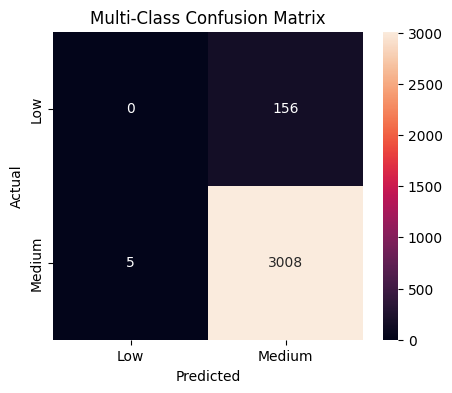

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use the SAME model you trained
dtm_pred = dtm.predict(X_test)

# Confusion matrix
cm = confusion_matrix(ym_test, dtm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Low", "Medium"],
            yticklabels=["Low", "Medium"])

plt.title("Multi-Class Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that the model is highly biased toward predicting the majority class (“Medium”). While it correctly classifies most Medium cases, it completely fails to identify any instances of the minority class (“Low”).

This indicates that the high accuracy (~95%) is misleading and does not reflect true model performance. The model struggles with class imbalance and is unable to distinguish less frequent usage patterns. This behavior is consistent with the class imbalance observed earlier.

Therefore, additional techniques such as class balancing or resampling may be required to improve performance on minority classes.

### Regression Models

In [31]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

Decision Trees

In [32]:
dtr = DecisionTreeRegressor(max_depth=5)
dtr.fit(X_train, yr_train)
pred = dtr.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(yr_test, pred)))

RMSE: 0.6945839190380274


The Decision Tree Regressor was used to predict the number of days of marijuana use. The model achieved an RMSE of approximately 0.69, indicating that predictions differ from actual values by less than one day on average.

This suggests that the model is able to capture general patterns in marijuana use frequency. However, decision trees can be sensitive to data variations and may not generalize as well as ensemble methods.

In [33]:
rfr = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rfr.fit(X_train, yr_train)

rfr_pred = rfr.predict(X_test)

rmse = np.sqrt(mean_squared_error(yr_test, rfr_pred))

print("Random Forest Regression RMSE:", rmse)

Random Forest Regression RMSE: 0.6935497387866673


The Random Forest Regressor slightly improved performance, achieving an RMSE of approximately 0.69, which is marginally lower than the decision tree model.

This improvement is due to the ensemble nature of random forests, which combine multiple trees to reduce variance and improve generalization. However, the improvement is relatively small, suggesting that the available features limit predictive power.

Boosting

In [34]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

X_train_clean = X_train.fillna(X_train.mean())
X_test_clean = X_test.fillna(X_train.mean())

gbr = GradientBoostingRegressor(n_estimators=150, random_state=42)
gbr.fit(X_train_clean, yr_train)

gbr_pred = gbr.predict(X_test_clean)

print("GB RMSE:", np.sqrt(mean_squared_error(yr_test, gbr_pred)))

GB RMSE: 0.6838296102127636


The Gradient Boosting Regressor achieved an RMSE of approximately 0.68, making it the best-performing model among the regression approaches.

Before training, missing values were handled using imputation, as Gradient Boosting does not support missing values natively.

The improved performance reflects the model’s ability to iteratively correct errors from previous trees, leading to more accurate predictions.

Comparison Regression

Overall, all regression models produced similar RMSE values (around 0.68–0.69), indicating consistent performance across approaches.

Ensemble methods such as Random Forest and Gradient Boosting slightly outperformed the single decision tree, suggesting better generalization.

However, the small differences in performance indicate that demographic and socioeconomic variables alone may not fully explain variation in marijuana use frequency.

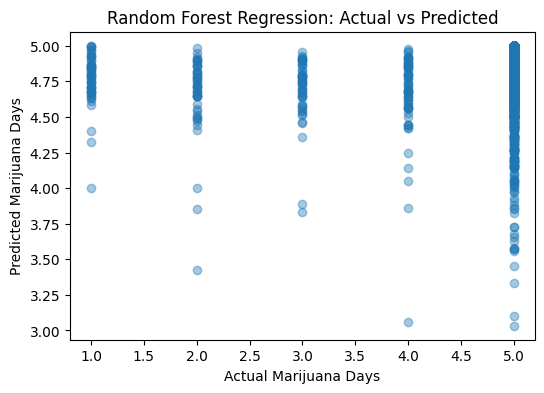

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(yr_test, rfr_pred, alpha=0.4)

plt.xlabel("Actual Marijuana Days")
plt.ylabel("Predicted Marijuana Days")
plt.title("Random Forest Regression: Actual vs Predicted")

plt.show()

The scatter plot compares actual marijuana use days with predicted values from the Random Forest model.

The points generally follow a positive trend, indicating that the model captures the overall relationship between features and the target variable. However, some dispersion is observed, suggesting that the model does not perfectly predict individual values.

This further supports the conclusion that while the model identifies general patterns, precise prediction of usage frequency remains challenging.

Feature Importance

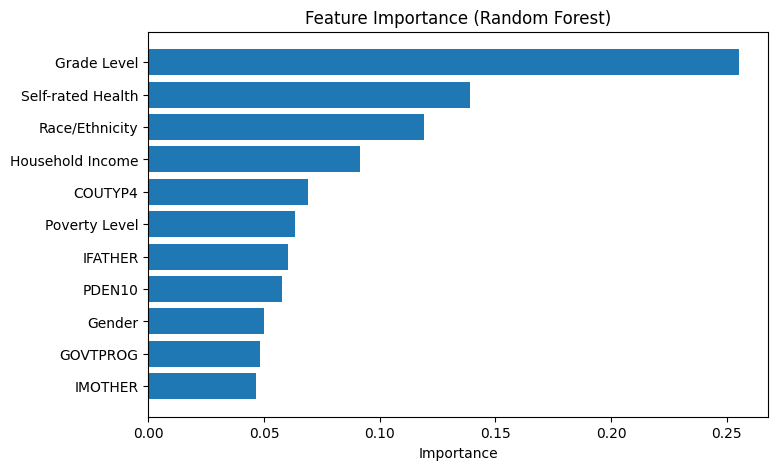

In [36]:

feature_labels = {
    'IRSEX': 'Gender',
    'NEWRACE2': 'Race/Ethnicity',
    'INCOME': 'Household Income',
    'POVERTY3': 'Poverty Level',
    'EDUSCHGRD2': 'Grade Level',
    'HEALTH2': 'Self-rated Health'
}

importances = rfm.feature_importances_
features = X_train.columns

# Create readable labels
clean_labels = []
for f in features:
    base = f.split("_")[0]  # removes one-hot suffix
    clean_labels.append(feature_labels.get(base, base))

importance_df = pd.DataFrame({
    "feature": clean_labels,
    "importance": importances
})

importance_grouped = importance_df.groupby("feature").sum().sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(importance_grouped.index, importance_grouped["importance"])

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

The feature importance plot highlights which variables contribute most to predicting marijuana use frequency.

Education level, health status, and socioeconomic factors such as income and poverty appear to be among the most influential predictors.

These findings suggest that both individual characteristics and environmental conditions play a role in shaping substance use behavior. However, these relationships should be interpreted cautiously, as they do not imply causation.

### Regression Insight

While the regression models achieve relatively low error, their predictive power is limited by the available features. The results suggest that additional behavioral or psychological variables may be necessary to better explain variation in marijuana use frequency. This highlights the complexity of substance use behavior and the limitations of purely demographic predictors

### Discussion

The results suggest that demographic and socioeconomic factors such as education level, health status, and income are associated with youth marijuana use. However, the models show limited ability to predict minority cases and precise usage levels, indicating that additional behavioral or environmental factors may play an important role.

These findings imply that public health interventions should consider broader social and contextual influences rather than relying solely on demographic characteristics.

### Ethical Considerations

This analysis involves sensitive data related to youth behavior and substance use.

Variables such as income, race, and gender may appear important in the model, but they do not imply causation. These relationships may reflect broader social and environmental factors.

There is a risk of reinforcing stereotypes if results are misinterpreted. Therefore, findings should be used responsibly to inform prevention and education efforts, not to label individuals or groups.

As data scientists, it is important to communicate results carefully, acknowledge limitations, and avoid biased conclusions.

### Conclusion

This study examined how demographic and socioeconomic factors relate to youth marijuana use using tree-based models. The results show that while models can capture general patterns, their predictive performance is limited, particularly for minority classes and detailed usage levels.

Ensemble methods slightly improved performance, but the findings highlight the importance of additional variables beyond demographics. These results can inform future research and support more targeted public health strategies.

Future work could incorporate behavioral or peer-related variables to improve predictive performance.